In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import load_model
from sklearn.model_selection import train_test_split

In [2]:
stock = yf.download("AAPL", start = "2015-01-01", end ="2025-01-01")
stock.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2015-01-02,24.214895,24.682228,23.776355,24.671153,212818400
2015-01-05,23.532721,24.064284,23.346674,23.984549,257142000
2015-01-06,23.534935,23.794071,23.173914,23.596950,263188400
2015-01-07,23.864946,23.964614,23.632387,23.743129,160423600
2015-01-08,24.781891,24.839477,24.075355,24.192743,237458000


In [3]:
stock.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2516 entries, 2015-01-02 to 2024-12-31
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   2516 non-null   float64
 1   (High, AAPL)    2516 non-null   float64
 2   (Low, AAPL)     2516 non-null   float64
 3   (Open, AAPL)    2516 non-null   float64
 4   (Volume, AAPL)  2516 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 117.9 KB


In [4]:
stock.describe()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,2516.000000,2516.000000,2516.000000,2516.000000,2.516000e+03
mean,93.771191,94.681846,92.758471,93.684447,1.170853e+08
std,65.380112,65.972982,64.694084,65.299975,6.839614e+07
min,20.584818,20.887872,20.386581,20.507347,2.323470e+07
25%,35.190024,35.587570,34.812313,35.210201,7.105610e+07
50%,64.327839,64.882052,63.526619,64.168528,1.003646e+08
75%,150.093563,151.839936,148.129118,149.916487,1.426216e+08
max,257.612732,258.686881,256.230300,256.787255,6.488252e+08


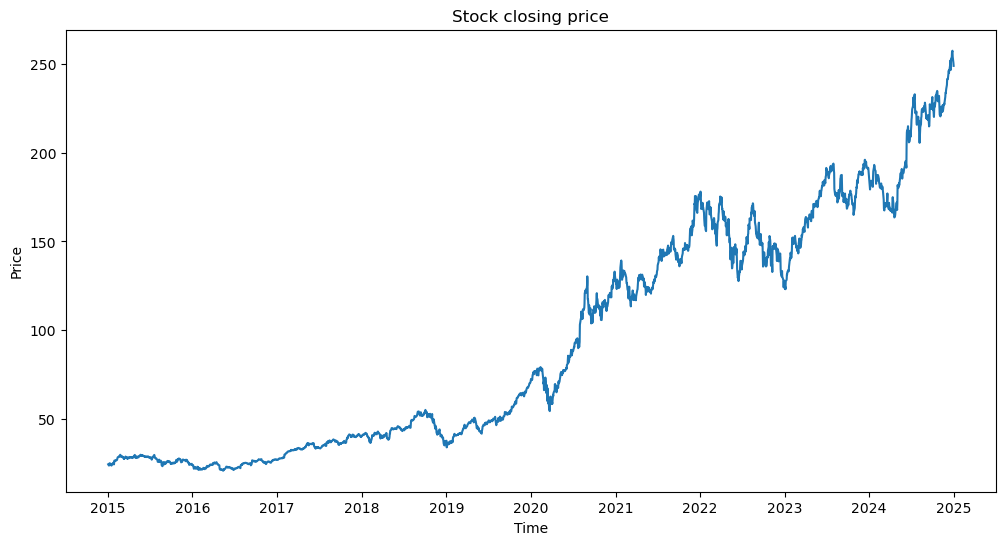

In [5]:
plt.figure(figsize=(12,6))
plt.plot(stock["Close"])
plt.title("Stock closing price")
plt.xlabel("Time")
plt.ylabel("Price")
plt.show()

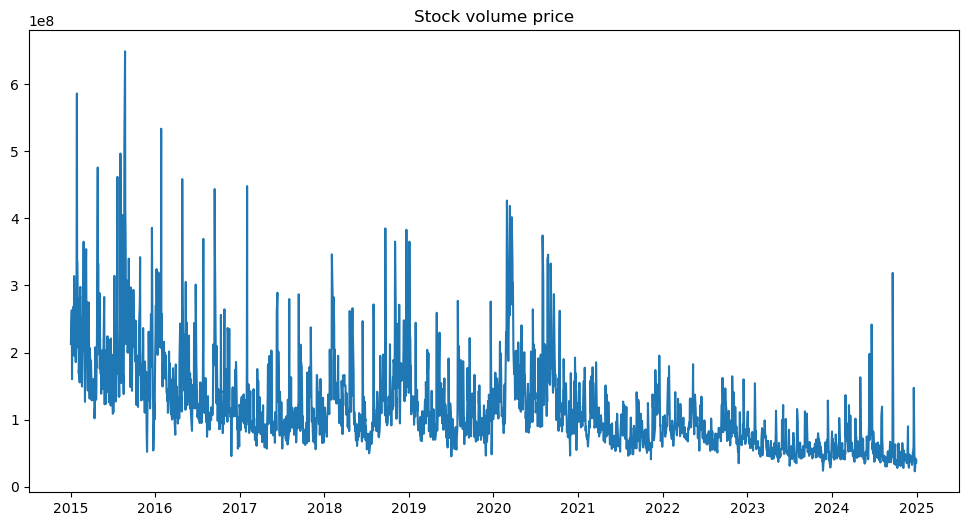

In [6]:
plt.figure(figsize = (12,6))
plt.plot(stock["Volume"])
plt.title("Stock volume price")
plt.show()

In [7]:
stock_symbol = input("Enter the stock symbol  (Example: AAPL or RELIANCE.NS): ")
stock = yf.download(stock_symbol, start = "2015-01-01",end ="2025-01-01")
stock.head()


Enter the stock symbol  (Example: AAPL or RELIANCE.NS):  TSLA


[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2015-01-02,14.620667,14.883333,14.217333,14.858000,71466000
2015-01-05,14.006000,14.433333,13.810667,14.303333,80527500
2015-01-06,14.085333,14.280000,13.614000,14.004000,93928500
2015-01-07,14.063333,14.318667,13.985333,14.223333,44526000
2015-01-08,14.041333,14.253333,14.000667,14.187333,51637500


In [8]:
stock.reset_index(inplace = True)
stock.head()

Price,Date,Close,High,Low,Open,Volume
Ticker,,TSLA,TSLA,TSLA,TSLA,TSLA
0,2015-01-02,14.620667,14.883333,14.217333,14.858000,71466000
1,2015-01-05,14.006000,14.433333,13.810667,14.303333,80527500
2,2015-01-06,14.085333,14.280000,13.614000,14.004000,93928500
3,2015-01-07,14.063333,14.318667,13.985333,14.223333,44526000
4,2015-01-08,14.041333,14.253333,14.000667,14.187333,51637500


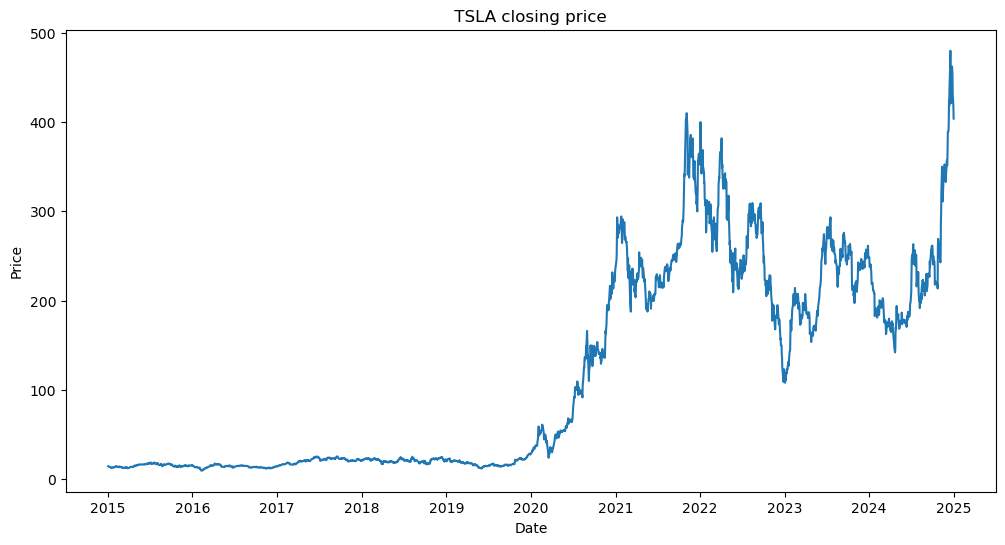

In [9]:
plt.figure(figsize = (12,6))
plt.plot(stock["Date"], stock["Close"])
plt.title(f" {stock_symbol} closing price ")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

In [10]:
stock["MA50"] = stock["Close"].rolling(50).mean()
stock["MA200"] = stock["Close"].rolling(200).mean()

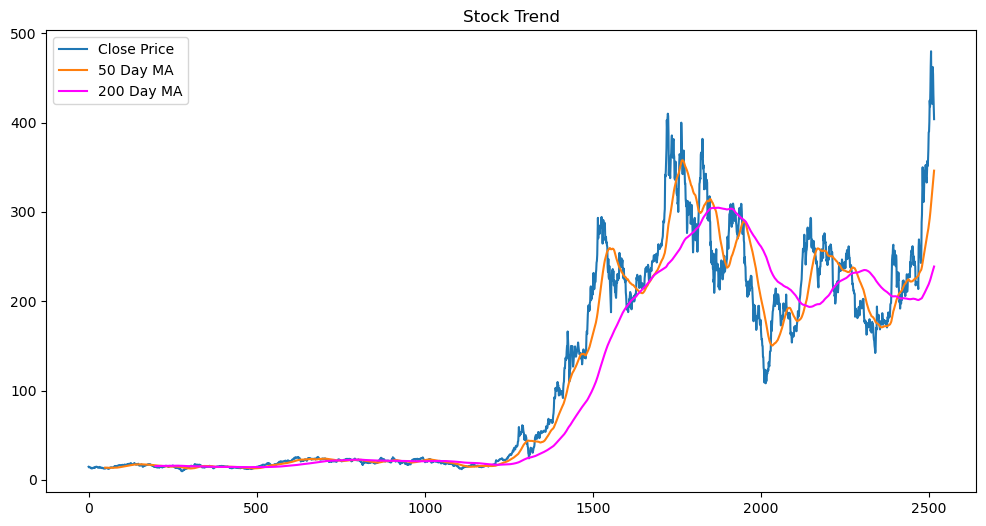

In [11]:
plt.figure(figsize=(12,6))

plt.plot(stock["Close"], label="Close Price")

plt.plot(stock["MA50"], label="50 Day MA")

plt.plot(stock["MA200"], label="200 Day MA", color ='magenta')

plt.legend()

plt.title("Stock Trend")

plt.show()

In [12]:
def backtest(stock):

    stock["Signal"] = 0

    stock.loc[stock["MA50"] > stock["MA200"], "Signal"] = 1
    stock.loc[stock["MA50"] < stock["MA200"], "Signal"] = -1

    stock["Returns"] = stock["Close"].pct_change()

    stock["Strategy"] = stock["Signal"].shift(1) * stock["Returns"]

    cumulative_return = (1 + stock["Strategy"]).cumprod()

    return cumulative_return

    


In [13]:
import ta

stock["RSI"] = ta.momentum.RSIIndicator(stock["Close"].squeeze()).rsi()

stock["MACD"] = ta.trend.MACD(stock["Close"].squeeze()).macd()

stock["Signal_Line"] = ta.trend.MACD(stock["Close"].squeeze()).macd_signal()


stock.tail()

Price,Date,Close,High,Low,Open,Volume,MA50,MA200,RSI,MACD,Signal_Line
Ticker,,TSLA,TSLA,TSLA,TSLA,TSLA,,,,,
2511,2024-12-24,462.279999,462.779999,435.140015,435.899994,59551800,329.6920,233.66755,68.422829,34.480358,34.539895
2512,2024-12-26,454.130005,465.329987,451.019989,465.160004,76366400,334.3832,235.05050,65.645587,34.011526,34.434221
2513,2024-12-27,431.660004,450.000000,426.500000,449.519989,82666800,338.5898,236.36140,58.585163,31.464133,33.840203
2514,2024-12-30,417.410004,427.000000,415.750000,419.399994,64941000,342.5202,237.63595,54.576261,27.972995,32.666762
2515,2024-12-31,403.839996,427.929993,402.540009,423.790009,76825100,346.1830,238.83730,50.997470,23.836484,30.900706


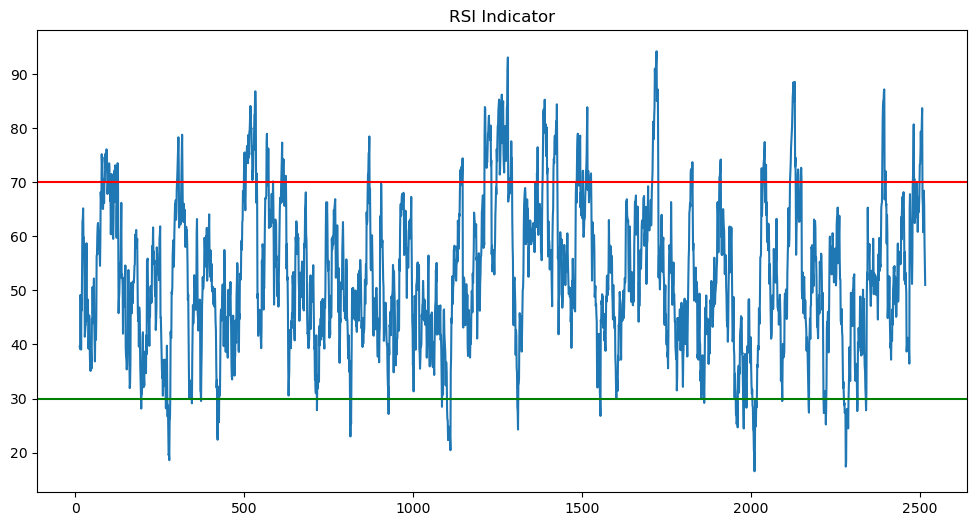

In [14]:
plt.figure(figsize = (12,6))
plt.plot(stock["RSI"])
plt.axhline(30 , color ='green')
plt.axhline(70 ,color = 'red')
plt.title("RSI Indicator")
plt.show()

In [15]:
data = stock[['Close']]
data.head()

Price,Close
Ticker,TSLA
0,14.620667
1,14.006000
2,14.085333
3,14.063333
4,14.041333


In [16]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range = (0,1))
scaled_data = scaler.fit_transform(data)
scaled_data[ :5]

array([[0.01072265],
       [0.00941563],
       [0.00958432],
       [0.00953754],
       [0.00949076]])

In [17]:
X = []
y = []
for i in range(60 , len(scaled_data)):
    X.append(scaled_data[i-60:i])
    y.append(scaled_data[i])

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)



(2456, 60, 1)
(2456, 1)


In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM,Dense

In [19]:
model = Sequential()
model.add(LSTM(50 ,return_sequences=True, input_shape=(X.shape[1],1)))
model.add(LSTM(50))
model.add(Dense(1))
model.compile(optimizer="adam", loss="mean_squared_error")

C:\Users\ABHINAV\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [20]:
model.fit(X, y, epochs=10, batch_size=32)

Epoch 1/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 17s 71ms/step - loss: 0.0068
Epoch 2/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 5s 70ms/step - loss: 0.0010    
Epoch 3/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 11s 73ms/step - loss: 8.3245e-04
Epoch 4/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 6s 73ms/step - loss: 7.0424e-04
Epoch 5/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 6s 74ms/step - loss: 6.5298e-04
Epoch 6/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 6s 77ms/step - loss: 6.1405e-04
Epoch 7/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 6s 76ms/step - loss: 5.3761e-04
Epoch 8/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 6s 73ms/step - loss: 4.7401e-04
Epoch 9/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 6s 71ms/step - loss: 4.9460e-04
Epoch 10/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 6s 74ms/step - loss: 4.5475e-04


In [21]:
import os
import joblib
os.makedirs("models", exist_ok=True)

model.save("models/lstm_model.h5")
joblib.dump(scaler, "models/scaler.pkl")


['models/scaler.pkl']

In [22]:
# Load LSTM model (TensorFlow / Keras)
from tensorflow.keras.models import load_model

lstm_model = load_model("models/lstm_model.h5")
print("LSTM Model loaded successfully")


# Load PPO model (Stable-Baselines3)
from stable_baselines3 import PPO

ppo_model = PPO.load("models/trading_agent.zip")
print("PPO Model loaded successfully")

LSTM Model loaded successfully
PPO Model loaded successfully


In [23]:
import os

print("LSTM size:", os.path.getsize("models/lstm_model.h5"))
print("PPO size:", os.path.getsize("models/trading_agent.zip"))

import h5py

h5py.File("models/lstm_model.h5", "r")

LSTM size: 407408
PPO size: 134074


<HDF5 file "lstm_model.h5" (mode r)>

In [24]:
predctions = model.predict(X)
predictions = scaler.inverse_transform(predctions)

77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step


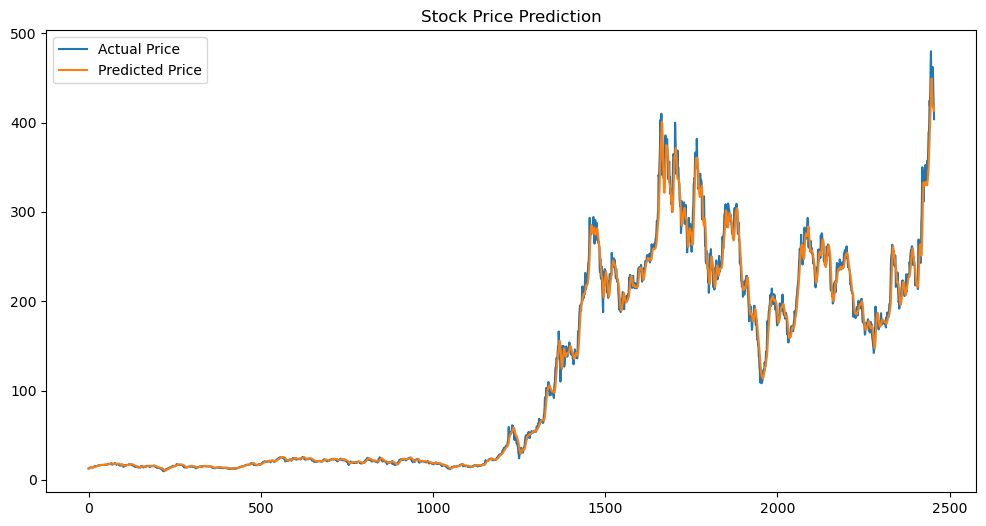

In [25]:
plt.figure(figsize =(12,6))
plt.plot(data.values[60:],label = "Actual Price")
plt.plot(predictions , label = "Predicted Price")
plt.legend()
plt.title("Stock Price Prediction")
plt.show()

In [26]:
stocks = [
"AAPL",
"TSLA",
"NVDA",
"RELIANCE.NS",
"TCS.NS",
"INFY.NS"
]

In [27]:
results = []

for s in stocks:
    
    stock= yf.download(s, period="1y")
    
    last_price = stock["Close"].iloc[-1].item()
    
    ma50 = stock["Close"].rolling(50).mean().iloc[-1].item()
    
    if last_price > ma50:
        signal = "BUY"
    else:
        signal = "SELL"
    
    results.append((s, last_price, signal))

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [28]:
df = pd.DataFrame(results, columns=["Stock","Price","Signal"])

df

,Stock,Price,Signal
0,AAPL,253.090103,SELL
1,TSLA,397.559906,SELL
2,NVDA,184.804993,SELL
3,RELIANCE.NS,1395.099976,SELL
4,TCS.NS,2409.199951,SELL
5,INFY.NS,1249.800049,SELL


In [29]:
def get_realtime_price(symbol):

    stock = yf.download(symbol, period="1d", interval="1m")

    last_price = stock["Close"].iloc[-1]

    return last_price


price = get_realtime_price("AAPL")

print("Current Price:", price)

[*********************100%***********************]  1 of 1 completed

Current Price: Ticker
AAPL    253.134995
Name: 2026-03-16 17:11:00+00:00, dtype: float64


In [30]:
last_60 = scaled_data[-60:]

last_60 = last_60.reshape(1,60,1)

predicted = model.predict(last_60)

predicted_price = scaler.inverse_transform(predicted)

print("Predicted Next Price:", predicted_price[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
Predicted Next Price: 403.87863


In [31]:
import feedparser
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

def get_news_sentiment(stock):

    url = f"https://news.google.com/rss/search?q={stock}+stock"
    feed = feedparser.parse(url)

    scores = []

    for entry in feed.entries[:10]:
        text = entry.title
        score = analyzer.polarity_scores(text)["compound"]
        scores.append(score)

    if len(scores) == 0:
        return 0

    return sum(scores)/len(scores)

In [32]:
current_price = price.iloc[-1]   # take latest price
predicted_price = float(np.squeeze(predicted_price))

if predicted_price > current_price:
    signal = "BUY"
else:
    signal = "SELL"

print("Trading Signal:", signal)

Trading Signal: BUY


In [33]:
stocks = [
"AAPL",
"TSLA",
"NVDA",
"MSFT",
"RELIANCE.NS",
"TCS.NS",
"INFY.NS"
]

recommendations = []

for s in stocks:
    
    stock= yf.download(s, period="1y")

    first_price = stock["Close"].iloc[0].item()
    last_price = stock["Close"].iloc[-1].item()

    returns = (last_price - first_price) / first_price

    recommendations.append((s, returns))

df = pd.DataFrame(recommendations, columns=["Stock", "Return"])

df = df.sort_values("Return", ascending=False)

print(df)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

         Stock    Return
1         TSLA  0.670266
2         NVDA  0.546754
0         AAPL  0.187959
4  RELIANCE.NS  0.130623
3         MSFT  0.034863
6      INFY.NS -0.190725
5       TCS.NS -0.287400


In [34]:
stock= yf.download("AAPL", period="1y")

# Clean columns
if isinstance(stock.columns, pd.MultiIndex):
    stock.columns = stock.columns.get_level_values(0)

stock["Close"] = stock["Close"].squeeze()

# Indicators
stock["MA50"] = stock["Close"].rolling(50).mean()

# Strategy
stock["Signal"] = 0

# Buy signal
stock.loc[stock["Close"] > stock["MA50"], "Signal"] = 1

# Strategy return
stock["Strategy_Return"] = (
    stock["Signal"].shift(1) * stock["Close"].pct_change()
)

[*********************100%***********************]  1 of 1 completed


In [35]:

stocks = ["AAPL","TSLA","NVDA","MSFT","RELIANCE.NS","TCS.NS"]

stock = yf.download(stocks, start="2020-01-01")["Close"]

stock.head()

[*********************100%***********************]  6 of 6 completed


Ticker,AAPL,MSFT,NVDA,RELIANCE.NS,TCS.NS,TSLA
Date,,,,,,
2020-01-01,NaN,NaN,NaN,675.324158,1866.114014,NaN
2020-01-02,72.400505,152.158417,5.970755,686.821228,1857.547485,28.684000
2020-01-03,71.696632,150.263748,5.875187,687.648804,1894.567139,29.534000
2020-01-06,72.267937,150.652130,5.899825,671.700684,1894.395020,30.102667
2020-01-07,71.928055,149.278564,5.971252,682.034546,1899.043945,31.270666


In [36]:
returns = stock.pct_change()

returns.head()

C:\Users\ABHINAV\AppData\Local\Temp\ipykernel_26096\2899262460.py:1: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = stock.pct_change()


Ticker,AAPL,MSFT,NVDA,RELIANCE.NS,TCS.NS,TSLA
Date,,,,,,
2020-01-01,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-02,NaN,NaN,NaN,0.017025,-0.004591,NaN
2020-01-03,-0.009722,-0.012452,-0.016006,0.001205,0.019929,0.029633
2020-01-06,0.007968,0.002585,0.004194,-0.023192,-0.000091,0.019255
2020-01-07,-0.004703,-0.009117,0.012107,0.015385,0.002454,0.038801


In [37]:
cov_matrix = returns.cov()

cov_matrix

Ticker,AAPL,MSFT,NVDA,RELIANCE.NS,TCS.NS,TSLA
Ticker,,,,,,
AAPL,0.000385,0.000248,0.000368,0.000041,0.000040,0.000388
MSFT,0.000248,0.000340,0.000399,0.000036,0.000040,0.000334
NVDA,0.000368,0.000399,0.001068,0.000069,0.000063,0.000634
RELIANCE.NS,0.000041,0.000036,0.000069,0.000300,0.000095,0.000086
TCS.NS,0.000040,0.000040,0.000063,0.000095,0.000218,0.000091
TSLA,0.000388,0.000334,0.000634,0.000086,0.000091,0.001664


In [38]:
mean_returns = returns.mean()

mean_returns

Ticker
AAPL           0.000970
MSFT           0.000764
NVDA           0.002651
RELIANCE.NS    0.000600
TCS.NS         0.000268
TSLA           0.002464
dtype: float64

In [39]:
num_portfolios = 5000

results = np.zeros((3, num_portfolios))

for i in range(num_portfolios):

    weights = np.random.random(len(stocks))
    weights /= np.sum(weights)

    portfolio_return = np.sum(weights * mean_returns) * 252

    portfolio_std = np.sqrt(np.dot(weights.T, np.dot(cov_matrix*252, weights)))

    results[0,i] = portfolio_return
    results[1,i] = portfolio_std
    results[2,i] = portfolio_return / portfolio_std

In [40]:
max_sharpe_idx = np.argmax(results[2])

best_return = results[0,max_sharpe_idx]
best_risk = results[1,max_sharpe_idx]

print("Best Portfolio Return:", best_return)
print("Best Portfolio Risk:", best_risk)

Best Portfolio Return: 0.44069959971646594
Best Portfolio Risk: 0.32081209242873016


In [41]:
best_weights = np.random.random(len(stocks))
best_weights /= np.sum(best_weights)

portfolio = pd.DataFrame({
    "Stock": stocks,
    "Allocation": best_weights
})

portfolio

,Stock,Allocation
0,AAPL,0.534005
1,TSLA,0.060960
2,NVDA,0.139964
3,MSFT,0.069432
4,RELIANCE.NS,0.110805
5,TCS.NS,0.084833


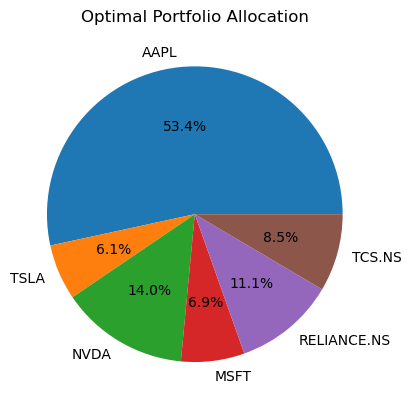

In [42]:
plt.pie(portfolio["Allocation"],
        labels=portfolio["Stock"],
        autopct='%1.1f%%')

plt.title("Optimal Portfolio Allocation")

plt.show()

In [43]:
import gymnasium as gym
import numpy as np

class TradingEnv(gym.Env):

    def __init__(self, prices):

        self.prices = prices
        self.step_index = 0
        self.balance = 1000
        self.shares = 0

        self.action_space = gym.spaces.Discrete(3)
        self.observation_space = gym.spaces.Box(
            low=0, high=np.inf, shape=(1,)
        )

    def reset(self, seed=None, options=None):
        self.step_index = 0
        return np.array([self.prices[self.step_index]]), {}

    def step(self, action):

        price = self.prices[self.step_index]

        if action == 1:
            self.shares += 1
            self.balance -= price

        elif action == 2 and self.shares > 0:
            self.shares -= 1
            self.balance += price

        self.step_index += 1

        done = self.step_index >= len(self.prices)-1

        value = self.balance + self.shares * price

        reward = value

        return np.array([price]), reward, done, False, {}

In [44]:
from stable_baselines3 import PPO
import yfinance as yf

stock = yf.download("AAPL", period="2y")

env = TradingEnv(stock["Close"].values)

model = PPO("MlpPolicy", env, verbose=1)
model.learn(total_timesteps=10000)

model.save("../models/rl_trader")

[*********************100%***********************]  1 of 1 completed


Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 499      |
|    ep_rew_mean     | 6.8e+05  |
| time/              |          |
|    fps             | 315      |
|    iterations      | 1        |
|    time_elapsed    | 6        |
|    total_timesteps | 2048     |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 499          |
|    ep_rew_mean          | 6.61e+05     |
| time/                   |              |
|    fps                  | 215          |
|    iterations           | 2            |
|    time_elapsed         | 18           |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 4.371346e-05 |
|    clip_fraction        | 0            |
|    clip_range           | 0.2          |
|    en

In [45]:


# For the Scaler
import joblib
joblib.dump(scaler, 'models/scaler.pkl')

['models/scaler.pkl']

In [46]:
model.save("models/trading_agent")

In [47]:
from stable_baselines3 import PPO
model = PPO.load("models/trading_agent")

In [57]:
import os
import pickle

os.makedirs("models", exist_ok=True)

# save scaler
with open("models/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

# ✅ SAVE LSTM (Keras)
lstm_model.save("models/lstm_model.keras")

# ✅ SAVE PPO (SB3)
ppo_model.save("models/trading_agent")

In [58]:
import os
import pickle
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler


model.save("models/trading_agent")


In [59]:
from stable_baselines3 import PPO

model = PPO.load("models/trading_agent")

In [61]:
# -------- LOAD MODELS --------

# LSTM
from tensorflow.keras.models import load_model
lstm_model = load_model("models/lstm_model.keras")

# PPO
from stable_baselines3 import PPO
ppo_model = PPO.load("models/trading_agent")

C:\Users\ABHINAV\AppData\Roaming\Python\Python313\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 18 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [62]:
print(type(lstm_model))
print(type(ppo_model))

<class 'keras.src.models.sequential.Sequential'>
<class 'stable_baselines3.ppo.ppo.PPO'>
